Nombre: Emilio Rico Hernández
Clase: 3
Challenge: Dashboard Analítico
Fecha: 2026-09-25

# Challenge 3 — Dashboard Analítico

Uso `ventas_2.csv` (6,000 transacciones de 2023 a 2025) y `regiones.csv`, para poner el nombre de cada región.

**El objetivo de este dashboard es responder:** ¿qué categorías y regiones concentran las ventas de la empresa y cómo han evolucionado entre 2023 y 2025?

Cada gráfica tiene título, ejes con unidades, una explicación de lo observado y las tres preguntas de reflexión del challenge. Uso azul para todo y naranja solo para resaltar.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

ventas = pd.read_csv("ventas_2.csv", parse_dates=["fecha"])
regiones = pd.read_csv("regiones.csv")
df = ventas.merge(regiones, on="region_id")
print("Filas y columnas:", df.shape)
df.head()

Filas y columnas: (6000, 11)


,fecha,region_id,vendedor,producto_id,cantidad,nombre_producto,categoria,precio_unitario,total,region,pais
0,2023-01-01,1,Vendedor_4,7,9,Producto 7,Electrónica,1932.73,17394.57,Norte,México
1,2023-01-01,3,Vendedor_10,5,5,Producto 5,Ropa,1240.04,6200.20,Centro,México
2,2023-01-01,5,Vendedor_6,1,1,Producto 1,Electrónica,1264.57,1264.57,Sureste,México
3,2023-01-01,4,Vendedor_9,14,3,Producto 14,Deportes,2949.45,8848.35,Bajío,México
4,2023-01-01,2,Vendedor_6,17,4,Producto 17,Ropa,1593.14,6372.56,Sur,México


## Indicadores (KPIs)

In [2]:
print(f"Ventas totales:     ${df['total'].sum():,.0f}")
print(f"Transacciones:      {len(df):,}")
print(f"Ticket promedio:    ${df['total'].mean():,.0f}")
print(f"Unidades vendidas:  {df['cantidad'].sum():,}")

por_anio = df.groupby(df["fecha"].dt.year)["total"].agg(["sum", "count", "mean"])
print(por_anio)
print("Ventas 2025 vs 2023:", round((por_anio.loc[2025, "sum"] / por_anio.loc[2023, "sum"] - 1) * 100, 1), "%")

Ventas totales:     $61,984,065
Transacciones:      6,000
Ticket promedio:    $10,331
Unidades vendidas:  36,411
               sum  count          mean
fecha                                  
2023   21113772.74   2059  10254.382098
2024   20842389.59   2005  10395.206778
2025   20027902.25   1936  10344.990832
Ventas 2025 vs 2023: -5.1 %


En tres años la empresa vendió $61,984,065 (unos $62.0 millones) en 6,000 transacciones y 36,411 unidades, con un ticket promedio de $10,331. El indicador que más me llama la atención es el último: las ventas de 2025 fueron 5.1% menores que las de 2023 (de $21.11 millones a $20.03 millones). En la tabla anual las transacciones bajaron de 2,059 a 1,936 y el ticket promedio (`mean`) casi no cambió ($10,254 a $10,345), así que la empresa no vende más barato: cierra menos ventas.

## Gráfica 1 — Barras: ventas por categoría

categoria
Deportes       41.4
Ropa           29.9
Electrónica    14.2
Hogar           8.0
Alimentos       6.4
Name: total, dtype: float64


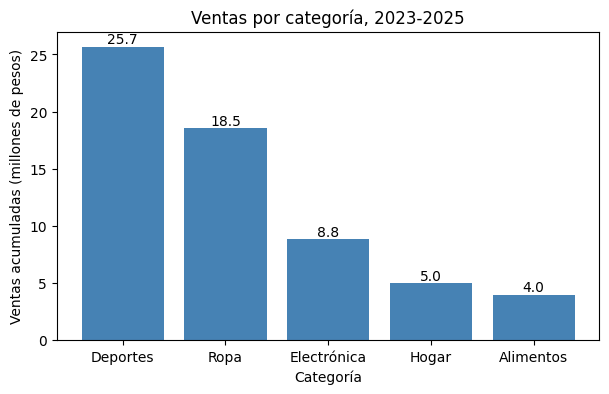

In [3]:
cat = df.groupby("categoria")["total"].sum().sort_values(ascending=False)
print((cat / cat.sum() * 100).round(1))

plt.figure(figsize=(7, 4))
barras = plt.bar(cat.index, cat.values / 1e6, color="steelblue")
plt.bar_label(barras, fmt="%.1f")
plt.title("Ventas por categoría, 2023-2025")
plt.xlabel("Categoría")
plt.ylabel("Ventas acumuladas (millones de pesos)")
plt.show()

**Lo observado:** Deportes es la categoría líder con $25.7 millones (41.4% de las ventas), seguida de Ropa con $18.5 millones (29.9%). Entre las dos suman 71% del total; Electrónica tiene 14.2%, Hogar 8.0% y Alimentos 6.4%.

- **¿Qué pregunta responde?** ¿Qué categorías concentran las ventas?
- **¿Por qué esta gráfica?** Las barras comparan un total entre pocas categorías, ordenadas de mayor a menor, y el eje empieza en cero.
- **Mensaje visual:** el negocio depende sobre todo de dos categorías, Deportes y Ropa.

## Gráfica 2 — Barras: ventas por región

region
Sur        20.7
Centro     20.5
Norte      19.8
Sureste    19.5
Bajío      19.4
Name: total, dtype: float64


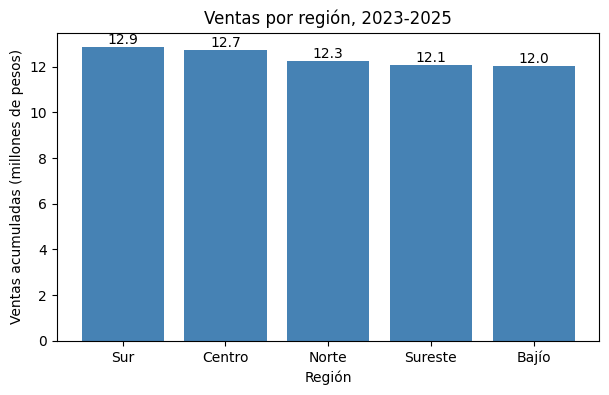

In [4]:
reg = df.groupby("region")["total"].sum().sort_values(ascending=False)
print((reg / reg.sum() * 100).round(1))


plt.figure(figsize=(7, 4))
barras = plt.bar(reg.index, reg.values / 1e6, color="steelblue")
plt.bar_label(barras, fmt="%.1f")
plt.title("Ventas por región, 2023-2025")
plt.xlabel("Región")
plt.ylabel("Ventas acumuladas (millones de pesos)")
plt.show()

**Lo observado:** las cinco regiones venden montos muy parecidos, de $12.0 millones (Bajío) a $12.9 millones (Sur). Cada una aporta cerca de 20% del total: Sur 20.7%, Centro 20.5%, Norte 19.8%, Sureste 19.5% y Bajío 19.4%.

- **¿Qué pregunta responde?** ¿Hay regiones que vendan mucho más o mucho menos que las demás?
- **¿Por qué esta gráfica?** Barras, porque comparo un total entre categorías, con el eje en cero para no exagerar diferencias pequeñas.
- **Mensaje visual:** no hay una región estrella ni una problemática; las ventas están repartidas de forma pareja.

## Gráfica 3 — Distribución del monto por transacción

count     6000.0
mean     10331.0
std       8153.0
min        162.0
25%       3285.0
50%       8215.0
75%      15586.0
max      36343.0
Name: total, dtype: float64


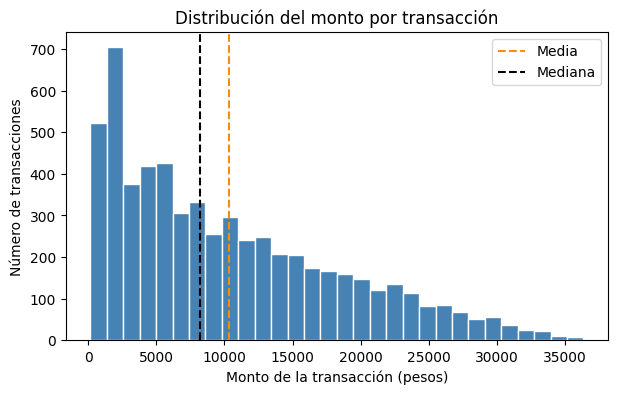

In [5]:
print(df["total"].describe().round(0))

plt.figure(figsize=(7, 4))
plt.hist(df["total"], bins=30, color="steelblue", edgecolor="white")
plt.axvline(df["total"].mean(), color="darkorange", linestyle="--", label="Media")
plt.axvline(df["total"].median(), color="black", linestyle="--", label="Mediana")
plt.title("Distribución del monto por transacción")
plt.xlabel("Monto de la transacción (pesos)")
plt.ylabel("Número de transacciones")
plt.legend()
plt.show()

**Lo observado:** hay muchas transacciones de monto bajo y una cola larga hacia la derecha. La mediana es $8,215 y la media $10,331; la mitad central de las ventas va de $3,285 a $15,586, y la más grande es de $36,343.

- **¿Qué pregunta responde?** ¿De qué tamaño suelen ser las ventas individuales?
- **¿Por qué esta gráfica?** Un histograma muestra la forma de una variable numérica: dónde se concentra y qué tan larga es la cola.
- **Mensaje visual:** la venta típica es de unos $8,000 y unas pocas ventas grandes jalan el promedio hacia arriba, así que la mediana describe mejor una venta normal.

## Gráfica 4 — Relación: precio unitario vs monto de la venta

                 cantidad  precio_unitario  total
cantidad             1.00             0.01   0.67
precio_unitario      0.01             1.00   0.67
total                0.67             0.67   1.00


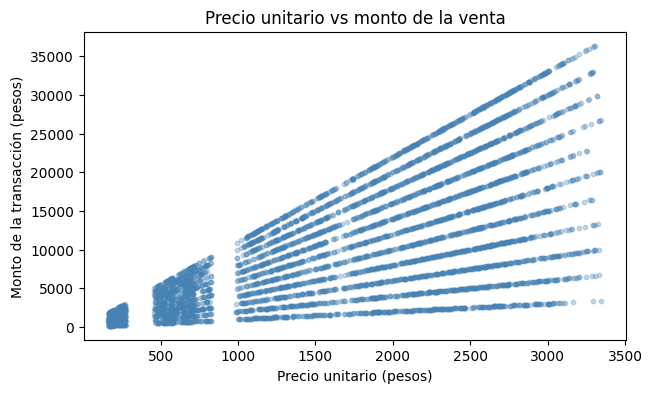

In [6]:
print(df[["cantidad", "precio_unitario", "total"]].corr().round(2))

plt.figure(figsize=(7, 4))
plt.scatter(df["precio_unitario"], df["total"], alpha=0.3, s=10, color="steelblue")
plt.title("Precio unitario vs monto de la venta")
plt.xlabel("Precio unitario (pesos)")
plt.ylabel("Monto de la transacción (pesos)")
plt.show()

**Lo observado:** el monto de la venta sube con el precio unitario (correlación de 0.67), pero también con la cantidad (0.67). Entre precio y cantidad casi no hay relación (0.01). Por eso la nube se abre en abanico: cada línea de puntos corresponde a una cantidad distinta de piezas, y se ven tres grupos de precio (menos de $300, entre $450 y $850, y más de $1,000).

- **¿Qué pregunta responde?** ¿El monto de una venta depende del precio del producto?
- **¿Por qué esta gráfica?** Un diagrama de dispersión es la forma directa de mostrar la relación entre dos variables numéricas.
- **Mensaje visual:** el monto depende tanto del precio como de la cantidad, y los productos caros no se compran en menor cantidad.

## Gráfica 5 — Temporal: ventas por mes

Mes más alto: 2023-12 2.13 millones
Mes más bajo: 2025-02 1.4 millones
Promedio móvil: primer valor 1.76 -> último 1.67
fecha        2023  2024  2025
categoria                    
Alimentos    1.28  1.36  1.35
Deportes     9.26  8.23  8.17
Electrónica  2.92  3.00  2.90
Hogar        1.68  1.63  1.65
Ropa         5.96  6.61  5.97


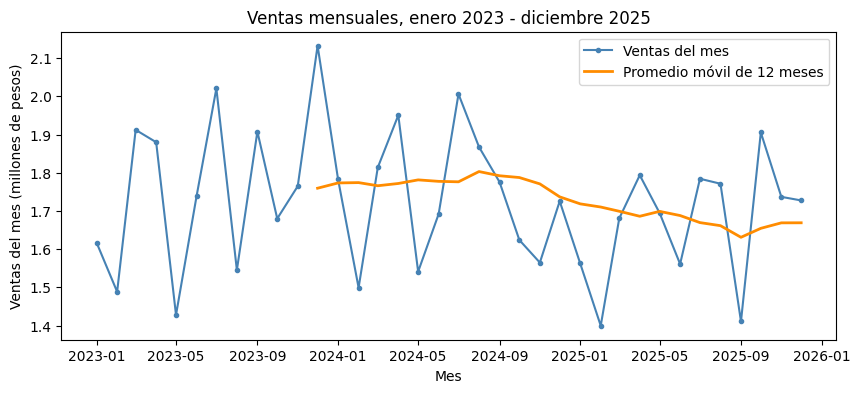

In [7]:
mensual = df.set_index("fecha")["total"].resample("MS").sum()
promedio_12 = mensual.rolling(12).mean()   # promedio móvil de 12 meses para ver la tendencia

plt.figure(figsize=(10, 4))
plt.plot(mensual.index, mensual.values / 1e6, marker="o", markersize=3, color="steelblue", label="Ventas del mes")
plt.plot(promedio_12.index, promedio_12.values / 1e6, color="darkorange", linewidth=2, label="Promedio móvil de 12 meses")
plt.title("Ventas mensuales, enero 2023 - diciembre 2025")
plt.xlabel("Mes")
plt.ylabel("Ventas del mes (millones de pesos)")
plt.legend()
plt.show()

print("Mes más alto:", mensual.idxmax().strftime("%Y-%m"), round(mensual.max() / 1e6, 2), "millones")
print("Mes más bajo:", mensual.idxmin().strftime("%Y-%m"), round(mensual.min() / 1e6, 2), "millones")
print("Promedio móvil: primer valor", round(promedio_12.dropna().iloc[0] / 1e6, 2), "-> último", round(promedio_12.iloc[-1] / 1e6, 2))
# ventas por categoría y año (millones), para ver qué categoría explica la tendencia
print(df.pivot_table(index="categoria", columns=df["fecha"].dt.year, values="total", aggfunc="sum").div(1e6).round(2))

**Lo observado:** las ventas del mes oscilan entre $1.40 millones (2025-02) y $2.13 millones (2023-12). El promedio móvil de 12 meses da una lectura más limpia: pasó de 1.76 millones (fin de 2023) a 1.67 millones (fin de 2025), con un punto más alto cerca de 1.8 millones a mediados de 2024. Es una baja lenta. La tabla por categoría y año muestra de dónde viene: Deportes bajó de 9.26 millones (2023) a 8.23 (2024) y 8.17 (2025), mientras que Ropa (5.96 a 5.97), Electrónica (2.92 a 2.90), Hogar (1.68 a 1.65) y Alimentos (1.28 a 1.35) casi no cambiaron entre 2023 y 2025.

- **¿Qué pregunta responde?** ¿Cómo han evolucionado las ventas en el tiempo?
- **¿Por qué esta gráfica?** Una línea, porque el tiempo es continuo y lo importante es la tendencia; agregué el promedio móvil para separarla del ruido de cada mes.
- **Mensaje visual:** las ventas no crecen; bajan poco a poco desde 2024, y casi toda la baja de 2025 contra 2023 se explica por Deportes.

## Conclusión

El objetivo del dashboard era saber qué categorías y regiones concentran las ventas y cómo han cambiado entre 2023 y 2025. En esos tres años la empresa vendió unos $62 millones en 6,000 transacciones, y más de 70% viene de dos categorías: Deportes (41.4%) y Ropa (29.9%). Entre regiones no hay diferencias importantes, porque cada una aporta cerca de 20%, así que la región no explica el desempeño.

La señal de alerta está en el tiempo: las ventas de 2025 fueron 5.1% menores que las de 2023 y el promedio móvil de 12 meses baja poco a poco desde mediados de 2024. La baja viene de menos transacciones (de 2,059 a 1,936) y no de un ticket menor, que se mantuvo cerca de $10,300, y se concentra en Deportes, que pasó de 9.26 a 8.17 millones mientras las otras categorías se mantuvieron.

Además, el monto de una venta depende del precio y de la cantidad por igual, y la venta típica (mediana de $8,215) es menor que el promedio. Como siguiente paso revisaría qué pasó en Deportes, por región y por producto, en 2024. Todo esto es descriptivo y no permite afirmar cuál fue la causa de la baja.